In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Data

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/TTU 2/Merged Dataset Final.csv")
df

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1891099363331432889,Sun Feb 16 12:16:37 +0000 2025,10,mandi mahasiswa hide cam https://t.co/WZTbmS1...,1891099363331432889,NaN,NaN,in,NaN,0,0,8,https://x.com/cuczks/status/1891099363331432889,2463829561,cuczks
1,1890763475871281480,Sat Feb 15 14:01:55 +0000 2025,5349,Hari ini kami mahasiswa UI merasa resah dengan...,1890763475871281480,https://pbs.twimg.com/media/Gj1XWxlaQAALYdz.jpg,NaN,in,"Depok, Indonesia",82,266,2419,https://x.com/bemuiofficial/status/18907634758...,1832036158173548545,bemuiofficial
2,1891056327016804523,Sun Feb 16 09:25:37 +0000 2025,512,damn besok kuliah https://t.co/lfw2ZQoo9O,1891056327016804523,https://pbs.twimg.com/media/Gj5htE-bkAA5F4T.jpg,NaN,in,paradise,68,38,155,https://x.com/urraaiinn/status/189105632701680...,1437716005657014276,urraaiinn
3,1891099083038724281,Sun Feb 16 12:15:30 +0000 2025,100,Koleksi toktokers yang lgi viral https://t.co/...,1891099083038724281,https://pbs.twimg.com/media/Gj6IldiaMAAtGOL.jpg,NaN,in,NaN,0,0,93,https://x.com/sepaqtuu/status/1891099083038724281,1877661005582577664,sepaqtuu
4,1889685319617839305,Wed Feb 12 14:37:43 +0000 2025,19241,gw rasa kuliah bukan passion gw passion gw bac...,1889685319617839305,NaN,NaN,in,NaN,820,161,7213,https://x.com/estfisip/status/1889685319617839305,1207505235255554048,estfisip
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24162,1892025908115956219,Wed Feb 19 01:38:23 +0000 2025,0,ceramah tarawih serasa kuliah umum,1892025908115956219,NaN,NaN,in,"Pauh, Indonesia",0,0,0,https://x.com/achtungkara/status/1892025908115...,1607355528459743235,achtungkara
24163,1892024158092927403,Wed Feb 19 01:31:26 +0000 2025,0,takut kok ama mahasiswa,1892024158092927403,NaN,NaN,in,NaN,0,0,0,https://x.com/sehabisjuni/status/1892024158092...,1142639306,sehabisjuni
24164,1892033115327271310,Wed Feb 19 02:07:01 +0000 2025,0,openn yaahh yukkk guyssss yg mau joki nyari ar...,1892033115327271310,NaN,NaN,in,NaN,0,0,0,https://x.com/namisuari/status/189203311532727...,1291025658584297481,namisuari
24165,1892031775888556213,Wed Feb 19 02:01:42 +0000 2025,15,w stress banget (masih pagi ini ajg) https://t...,1892031775888556213,NaN,NaN,in,ⓘ RPS multiship,0,0,0,https://x.com/alelithereal/status/189203177588...,1278082017901477888,alelithereal


In [ ]:
df = df.rename(columns={'full_text': 'Text'})

# Data Cleaning

In [ ]:
df.drop(columns = ["image_url", "in_reply_to_screen_name", "location", "conversation_id_str", "created_at", "favorite_count", "id_str", "lang", "quote_count", "reply_count", "retweet_count", "tweet_url", "user_id_str", "username"], axis = 1, inplace = True)

In [ ]:
df

,Text
0,mandi mahasiswa hide cam https://t.co/WZTbmS1...
1,Hari ini kami mahasiswa UI merasa resah dengan...
2,damn besok kuliah https://t.co/lfw2ZQoo9O
3,Koleksi toktokers yang lgi viral https://t.co/...
4,gw rasa kuliah bukan passion gw passion gw bac...
...,...
24162,ceramah tarawih serasa kuliah umum
24163,takut kok ama mahasiswa
24164,openn yaahh yukkk guyssss yg mau joki nyari ar...
24165,w stress banget (masih pagi ini ajg) https://t...


In [ ]:
# Menghitung duplikasi pada kolom 'full_text'
duplicate_count_tweet = df.duplicated(subset=['Text']).sum()
print(f"Jumlah data duplikat pada kolom Text : {duplicate_count_tweet}")

Jumlah data duplikat pada kolom Text : 15788


In [ ]:
# Menampilkan duplikasi dalam data
duplicate_rows = df[df.duplicated(subset=['Text'], keep=False)]
duplicate_rows

,Text
0,mandi mahasiswa hide cam https://t.co/WZTbmS1...
1,Hari ini kami mahasiswa UI merasa resah dengan...
2,damn besok kuliah https://t.co/lfw2ZQoo9O
3,Koleksi toktokers yang lgi viral https://t.co/...
4,gw rasa kuliah bukan passion gw passion gw bac...
...,...
24162,ceramah tarawih serasa kuliah umum
24163,takut kok ama mahasiswa
24164,openn yaahh yukkk guyssss yg mau joki nyari ar...
24165,w stress banget (masih pagi ini ajg) https://t...


In [ ]:
# Menghapus duplikat pada kolom 'Text' dan menyimpannya pada variabel tweet_cleaned
tweet = df.drop_duplicates(subset=['Text'], keep='first')

# Menampilkan jumlah data setelah duplikat dihapus
print(f"Jumlah data setelah eliminasi duplikat : {tweet.shape[0]}")

Jumlah data setelah eliminasi duplikat : 8379


In [ ]:
import re

def remove (text):
  # Mendefinisikan kata kunci
  keywords = ["toktokers", "geoya", "hide", "vcs", "g0als"]

  # Menggunakan ekspresi reguler untuk menemukan kata kunci, bahkan jika berada di dalam kata lain
  for keyword in keywords:
    if re.search(r'\b' + re.escape(keyword) + r'\b', text): # \b memastikan pencocokan kata utuh
      return "" # Atau kembalikan np.nan, tergantung pada apa yang ingin Anda lakukan dengan baris yang dihapus

  return text

# Menerapkan fungsi ke kolom 'Text' Anda
# Menerapkan fungsi 'remove' ke setiap nilai dalam kolom 'Text' pada DataFrame 'tweet'
tweet.loc[:, 'Text'] = tweet['Text'].apply(remove)

# Menghapus baris di mana kolom 'Text' tidak lagi isi karena penghapusan keyword
tweet = tweet[tweet['Text'] != ""]

# Menampilkan dataframe yang diperbarui
print(f"Jumlah data setelah eliminasi kata kunci tidak relevan : {tweet.shape[0]}")

Jumlah data setelah eliminasi kata kunci tidak relevan : 8318


In [ ]:
tweet

,Text
1,Hari ini kami mahasiswa UI merasa resah dengan...
2,damn besok kuliah https://t.co/lfw2ZQoo9O
4,gw rasa kuliah bukan passion gw passion gw bac...
5,lu pada stres gasi ngeliat dk casual mode ceo ...
6,like i struggle to bayar ukt kuliah but im not...
...,...
23161,ceramah tarawih serasa kuliah umum
23162,takut kok ama mahasiswa
23163,openn yaahh yukkk guyssss yg mau joki nyari ar...
23164,w stress banget (masih pagi ini ajg) https://t...


# Case Folding

In [ ]:
# Using Series.str.lower() function on Pandas
tweet['Text Case Folding'] = tweet['Text'].str.lower()

# Case Folding Result
tweet['Text Case Folding'].head()

<ipython-input-11-95f2b65dcf12>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweet['Text Case Folding'] = tweet['Text'].str.lower()


,Text Case Folding
1,hari ini kami mahasiswa ui merasa resah dengan...
2,damn besok kuliah https://t.co/lfw2zqoo9o
4,gw rasa kuliah bukan passion gw passion gw bac...
5,lu pada stres gasi ngeliat dk casual mode ceo ...
6,like i struggle to bayar ukt kuliah but im not...


# Text Clening

In [ ]:
import string

def remove_tweet_special(text):
    # remove tab, new line, ans back slice
    text = text.replace('\\t'," ").replace('\\n'," ").replace('\\u'," ").replace('\\',"")
    # remove non ASCII (emoticon, chinese word, .etc)
    text = text.encode('ascii', 'replace').decode('ascii')
    # remove mention, link, hashtag
    text = ' '.join(re.sub("([@#][A-Za-z0-9]+)|(\w+:\/\/\S+)"," ", text).split())
    # remove incomplete URL
    return text.replace("http://", " ").replace("https://", " ")

tweet['Text Case Folding'] = tweet['Text Case Folding'].apply(remove_tweet_special)

#remove number
def remove_number(text):
    return  re.sub(r"\d+", "", text)

tweet['Text Case Folding'] = tweet['Text Case Folding'].apply(remove_number)

#remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans("","",string.punctuation))

tweet['Text Case Folding'] = tweet['Text Case Folding'].apply(remove_punctuation)

#remove whitespace leading & trailing
def remove_whitespace_LT(text):
    return text.strip()

tweet['Text Case Folding'] = tweet['Text Case Folding'].apply(remove_whitespace_LT)

#remove multiple whitespace into single whitespace
def remove_whitespace_multiple(text):
    return re.sub('\s+',' ',text)

tweet['Text Case Folding'] = tweet['Text Case Folding'].apply(remove_whitespace_multiple)

# remove single char
def remove_singl_char(text):
    return re.sub(r"\b[a-zA-Z]\b", "", text)

tweet['Text Cleaning'] = tweet['Text Case Folding'].apply(remove_singl_char)
# Cleaning Result
tweet['Text Cleaning'].head()

,Text Cleaning
1,hari ini kami mahasiswa ui merasa resah dengan...
2,damn besok kuliah
4,gw rasa kuliah bukan passion gw passion gw bac...
5,lu pada stres gasi ngeliat dk casual mode ceo ...
6,like struggle to bayar ukt kuliah but im not ...


# Tokenizing

In [ ]:
import re #regex library
import nltk
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize # import word_tokenize

# NLTK word rokenize
def word_tokenize_wrapper(text):
    return word_tokenize(text)

tweet['Text Tokenizing'] = tweet['Text Cleaning'].apply(word_tokenize_wrapper)

# Tokenizing Result
tweet['Text Tokenizing'].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text Tokenizing
1,"[hari, ini, kami, mahasiswa, ui, merasa, resah..."
2,"[damn, besok, kuliah]"
4,"[gw, rasa, kuliah, bukan, passion, gw, passion..."
5,"[lu, pada, stres, gasi, ngeliat, dk, casual, m..."
6,"[like, struggle, to, bayar, ukt, kuliah, but, ..."


# Normalization

In [ ]:
normalizad_word = pd.read_excel("/content/drive/MyDrive/TTU 2/kamuskatabaku.xlsx")

normalizad_word_dict = {}

for index, row in normalizad_word.iterrows():
    if row[0] not in normalizad_word_dict:
        normalizad_word_dict[row[0]] = row[1]

def normalized_term(document):
    return [normalizad_word_dict[term] if term in normalizad_word_dict else term for term in document]

tweet['Text Normalization'] = tweet['Text Tokenizing'].apply(normalized_term)

# Tokenizing Result
tweet['Text Normalization'].head()

<ipython-input-14-a9d4cce40e16>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] not in normalizad_word_dict:
<ipython-input-14-a9d4cce40e16>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalizad_word_dict[row[0]] = row[1]


,Text Normalization
1,"[hari, ini, kami, mahasiswa, ui, merasa, resah..."
2,"[damn, besok, kuliah]"
4,"[gue, rasa, kuliah, bukan, passion, gue, passi..."
5,"[lu, pada, stres, gasi, melihat, dk, casual, m..."
6,"[like, struggle, tapi, bayar, ukt, kuliah, but..."


# Stemming

In [ ]:
# import Sastrawi package
!pip install Sastrawi
!pip install swifter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

# create stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# stemmed
def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}

for document in tweet['Text Normalization']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

print(len(term_dict))
print("------------------------")

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term,":" ,term_dict[term])

print(term_dict)
print("------------------------")

# apply stemmed term to dataframe
def get_stemmed_term(document):
    return [term_dict[term] for term in document]

tweet['Text Stemming'] = tweet['Text Normalization'].swifter.apply(get_stemmed_term)
print(tweet['Text Stemming'])

Output streaming akan dipotong hingga 5000 baris terakhir.
jobless : jobless
sialnya : sial
dramadrama : dramadrama
mengagumi : kagum
nelen : nelen
keputihan : putih
gaksiiii : gaksiiii
pipis : pipis
linu : linu
apaapanya : apaapanya
offering : offering
letter : letter
ketolongan : tolong
terdekatlah : dekat
wajarkan : wajar
ros : ros
ngejadiin : ngejadiin
ketempat : tempat
caloncalon : caloncalon
panjenengan : panjenengan
sepelein : sepelein
membenci : benci
merepespon : merepespon
terserap : serap
batasi : batas
interaskinya : interaskinya
mentertawakan : tertawa
ditreat : ditreat
salahsalahan : salahsalahan
barengbareng : barengbareng
sejatinya : sejati
disayang : sayang
ngecover : ngecover
kelilit : lilit
sebanyaknya : banyak
dilike : dilike
ngelepas : ngelepas
diperhatiin : diperhatiin
enakenaknya : enakenaknya
pollllll : pollllll
terkena : kena
hipersomnia : hipersomnia
pemicu : picu
sesensitif : sensitif
kalao : kalao
bonafit : bonafit
iqbaloo : iqbaloo
jamjam : jamjam
pertamax 

Pandas Apply:   0%|          | 0/8318 [00:00<?, ?it/s]

1        [hari, ini, kami, mahasiswa, ui, rasa, resah, ...
2                                    [damn, besok, kuliah]
4        [gue, rasa, kuliah, bukan, passion, gue, passi...
5        [lu, pada, stres, gas, lihat, dk, casual, mode...
6        [like, struggle, tapi, bayar, ukt, kuliah, but...
                               ...                        
23161             [ceramah, tarawih, serasa, kuliah, umum]
23162                        [takut, kok, sama, mahasiswa]
23163    [openn, ya, yuk, guyssss, yang, mau, joki, car...
23164               [stres, banget, masih, pagi, ini, ajg]
23165    [kemarin, pas, scrolling, linkedin, betul, nem...
Name: Text Stemming, Length: 8318, dtype: object


# Filtering

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

# ----------------------- get stopword from NLTK stopword -------------------------------
# get stopword indonesia
list_stopwords = stopwords.words('indonesian')


# ---------------------------- manualy add stopword  ------------------------------------
# append additional stopword
list_stopwords.extend(["yg", "dg", "rt", "dgn", "ny", 'klo', 'kalo', 'amp', 'biar', 'bikin',
                       'bilang', 'gak', 'ga', 'krn', 'nya', 'nih', 'sih','si', 'tau', 'tdk',
                       'tuh', 'utk', 'ya', 'jd', 'jgn', 'sdh', 'aja', 'nyg', 'hehe', 'pen',
                       'u', 'nan', 'loh', 'rt', '&amp', 'yah', 'sdgkan', 'sdg', 'emg', 'sm',
                       'pls', 'mlu', 'ken', 'allah', 'brb', 'btw', 'b/c', 'cod', 'cmiiw',
                       'fyi', 'gg', 'ggwp', 'idk', 'ikr', 'lol', 'ootd', 'lmao', 'oot', 'pap',
                       'otw', 'tfl', 'vc', 'ygy', 'ah'])

# ----------------------- add stopword from txt file ------------------------------------
# read txt stopword using pandas
txt_stopword = pd.read_csv("/content/drive/MyDrive/TTU 2/stopwordbahasa.txt", names= ["stopwords"], header = None)

# convert stopword string to list & append additional stopword
list_stopwords.extend(txt_stopword["stopwords"][0].split(' '))

# ---------------------------------------------------------------------------------------

# convert list to dictionary
list_stopwords = set(list_stopwords)


#remove stopword pada list token
def stopwords_removal(words):
    return [word for word in words if word not in list_stopwords]

tweet['Text Filtering'] = tweet['Text Stemming'].apply(stopwords_removal)


tweet['Text Filtering']

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Text Filtering
1,"[mahasiswa, ui, resah, kondisi, bangsa, akhira..."
2,"[damn, besok, kuliah]"
4,"[gue, kuliah, passion, gue, passion, gue, baca..."
5,"[lu, stres, gas, lihat, dk, casual, mode, ceo,..."
6,"[like, struggle, bayar, ukt, kuliah, but, im, ..."
...,...
23161,"[ceramah, tarawih, serasa, kuliah]"
23162,"[takut, mahasiswa]"
23163,"[openn, yuk, guyssss, joki, cari, artikel, res..."
23164,"[stres, banget, pagi, ajg]"


# View Preprocessing Results

In [ ]:
tweet

,Text,Text Case Folding,Text Cleaning,Text Tokenizing,Text Normalization,Text Stemming,Text Filtering
1,Hari ini kami mahasiswa UI merasa resah dengan...,hari ini kami mahasiswa ui merasa resah dengan...,hari ini kami mahasiswa ui merasa resah dengan...,"[hari, ini, kami, mahasiswa, ui, merasa, resah...","[hari, ini, kami, mahasiswa, ui, merasa, resah...","[hari, ini, kami, mahasiswa, ui, rasa, resah, ...","[mahasiswa, ui, resah, kondisi, bangsa, akhira..."
2,damn besok kuliah https://t.co/lfw2ZQoo9O,damn besok kuliah,damn besok kuliah,"[damn, besok, kuliah]","[damn, besok, kuliah]","[damn, besok, kuliah]","[damn, besok, kuliah]"
4,gw rasa kuliah bukan passion gw passion gw bac...,gw rasa kuliah bukan passion gw passion gw bac...,gw rasa kuliah bukan passion gw passion gw bac...,"[gw, rasa, kuliah, bukan, passion, gw, passion...","[gue, rasa, kuliah, bukan, passion, gue, passi...","[gue, rasa, kuliah, bukan, passion, gue, passi...","[gue, kuliah, passion, gue, passion, gue, baca..."
5,lu pada stres gasi ngeliat dk casual mode ceo ...,lu pada stres gasi ngeliat dk casual mode ceo ...,lu pada stres gasi ngeliat dk casual mode ceo ...,"[lu, pada, stres, gasi, ngeliat, dk, casual, m...","[lu, pada, stres, gasi, melihat, dk, casual, m...","[lu, pada, stres, gas, lihat, dk, casual, mode...","[lu, stres, gas, lihat, dk, casual, mode, ceo,..."
6,like i struggle to bayar ukt kuliah but im not...,like i struggle to bayar ukt kuliah but im not...,like struggle to bayar ukt kuliah but im not ...,"[like, struggle, to, bayar, ukt, kuliah, but, ...","[like, struggle, tapi, bayar, ukt, kuliah, but...","[like, struggle, tapi, bayar, ukt, kuliah, but...","[like, struggle, bayar, ukt, kuliah, but, im, ..."
...,...,...,...,...,...,...,...
23161,ceramah tarawih serasa kuliah umum,ceramah tarawih serasa kuliah umum,ceramah tarawih serasa kuliah umum,"[ceramah, tarawih, serasa, kuliah, umum]","[ceramah, tarawih, serasa, kuliah, umum]","[ceramah, tarawih, serasa, kuliah, umum]","[ceramah, tarawih, serasa, kuliah]"
23162,takut kok ama mahasiswa,takut kok ama mahasiswa,takut kok ama mahasiswa,"[takut, kok, ama, mahasiswa]","[takut, kok, sama, mahasiswa]","[takut, kok, sama, mahasiswa]","[takut, mahasiswa]"
23163,openn yaahh yukkk guyssss yg mau joki nyari ar...,openn yaahh yukkk guyssss yg mau joki nyari ar...,openn yaahh yukkk guyssss yg mau joki nyari ar...,"[openn, yaahh, yukkk, guyssss, yg, mau, joki, ...","[openn, ya, yuk, guyssss, yang, mau, joki, men...","[openn, ya, yuk, guyssss, yang, mau, joki, car...","[openn, yuk, guyssss, joki, cari, artikel, res..."
23164,w stress banget (masih pagi ini ajg) https://t...,w stress banget masih pagi ini ajg,stress banget masih pagi ini ajg,"[stress, banget, masih, pagi, ini, ajg]","[stres, banget, masih, pagi, ini, ajg]","[stres, banget, masih, pagi, ini, ajg]","[stres, banget, pagi, ajg]"


# Save Preprocessing Results

In [ ]:
tweet.to_csv("preprocessing results", index=False)

# Delete Unnecessary Data

In [ ]:
df= tweet.drop(columns=['Text', 'Text Case Folding', 'Text Cleaning', 'Text Tokenizing', 'Text Normalization', 'Text Stemming'])
df.head()

,Text Filtering
1,"[mahasiswa, ui, resah, kondisi, bangsa, akhira..."
2,"[damn, besok, kuliah]"
4,"[gue, kuliah, passion, gue, passion, gue, baca..."
5,"[lu, stres, gas, lihat, dk, casual, mode, ceo,..."
6,"[like, struggle, bayar, ukt, kuliah, but, im, ..."


# Labeling Using Inset Lexicon

In [ ]:
lexicon_positive = pd.read_excel('/content/drive/MyDrive/TTU 2/kamus_positive.xlsx')
lexicon_positive_dict = {}
for index, row in lexicon_positive.iterrows():
    if row[0] not in lexicon_positive_dict:
        lexicon_positive_dict[row[0]] = row[1]

lexicon_negative = pd.read_excel('/content/drive/MyDrive/TTU 2/kamus_negative.xlsx')
lexicon_negative_dict = {}
for index, row in lexicon_negative.iterrows():
    if row[0] not in lexicon_negative_dict:
        lexicon_negative_dict[row[0]] = row[1]

def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text:
        if (word in lexicon_positive_dict):
            score = score + lexicon_positive_dict[word]
    for word in text:
        if (word in lexicon_negative_dict):
            score = score + lexicon_negative_dict[word]
    sentimen=''
    if (score >= 0):
        sentimen = 'Positive'
    else:
        sentimen = 'Negative'
    return score, sentimen

results = df['Text Filtering'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['Polarity Score'] = results[0]
df['Indonesia Sentiment'] = results[1]

df[['Text Filtering','Polarity Score','Indonesia Sentiment']]

,Text Filtering,Polarity Score,Indonesia Sentiment
1,"[mahasiswa, ui, resah, kondisi, bangsa, akhira...",-7,Negative
2,"[damn, besok, kuliah]",-1,Negative
4,"[gue, kuliah, passion, gue, passion, gue, baca...",1,Positive
5,"[lu, stres, gas, lihat, dk, casual, mode, ceo,...",-6,Negative
6,"[like, struggle, bayar, ukt, kuliah, but, im, ...",-6,Negative
...,...,...,...
23161,"[ceramah, tarawih, serasa, kuliah]",-1,Negative
23162,"[takut, mahasiswa]",-3,Negative
23163,"[openn, yuk, guyssss, joki, cari, artikel, res...",-2,Negative
23164,"[stres, banget, pagi, ajg]",-7,Negative


## Sentiment Cumulative Results

In [ ]:
inset_counts = df['Indonesia Sentiment'].value_counts()
inset_counts

,count
Indonesia Sentiment,
Negative,5663
Positive,2655


## Save Labeling Results

In [ ]:
df.to_csv("sentiment results", index=False)

## Labeling Results Visualization

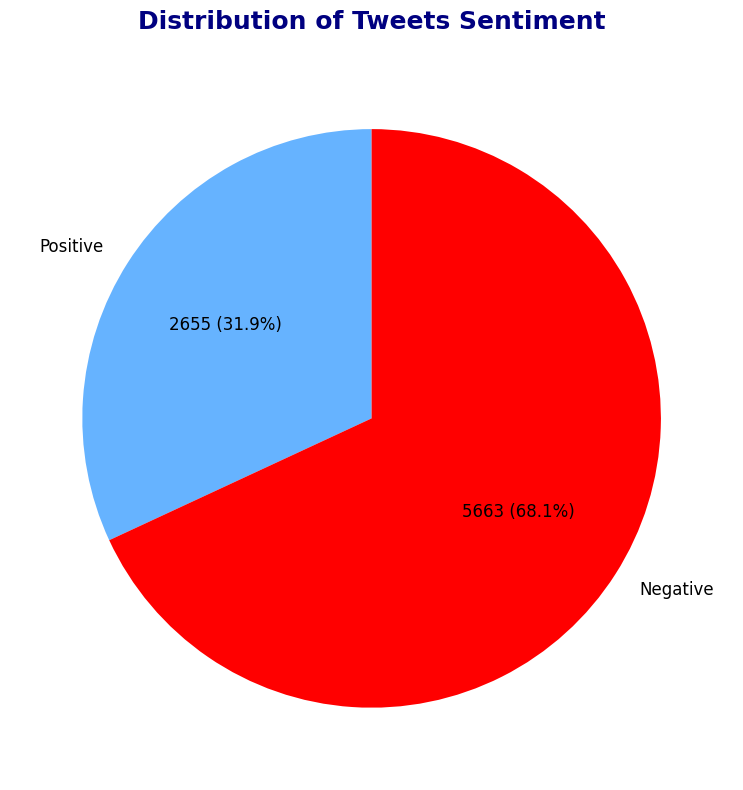

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas to read the CSV

# Load the data from the CSV file
df_inset1 = pd.read_csv("sentiment results")

# Assuming 'df_inset1' has the 'Indonesia Sentiment' column
sentiment_counts = df_inset1['Indonesia Sentiment'].value_counts()

# Reorder sentiment_counts to ensure 'Positive' is first
sentiment_counts = sentiment_counts.reindex(['Positive', 'Negative'])

# Creating the pie chart
plt.figure(figsize=(8, 8))  # Adjust figure size if needed
colors = ['#66b3ff', 'red']  # Colors for Positive and Negative

# Creating the pie chart with autopct function for custom labels
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d} ({p:.1f}%)'.format(p=pct,v=val) # Format diubah menjadi jumlah (persen)
    return my_autopct

plt.pie(sentiment_counts, labels=sentiment_counts.index,
        autopct=make_autopct(sentiment_counts), # Use custom autopct function
        startangle=90, colors=colors, textprops={'fontsize': 12})

# Adding a title
plt.title("Distribution of Tweets Sentiment", loc="center", fontsize=18,
          color="#000080", pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("sentiment results")

df

,Text Filtering,Polarity Score,Indonesia Sentiment
0,"['mahasiswa', 'ui', 'resah', 'kondisi', 'bangs...",-7,Negative
1,"['damn', 'besok', 'kuliah']",-1,Negative
2,"['gue', 'kuliah', 'passion', 'gue', 'passion',...",1,Positive
3,"['lu', 'stres', 'gas', 'lihat', 'dk', 'casual'...",-6,Negative
4,"['like', 'struggle', 'bayar', 'ukt', 'kuliah',...",-6,Negative
...,...,...,...
8313,"['ceramah', 'tarawih', 'serasa', 'kuliah']",-1,Negative
8314,"['takut', 'mahasiswa']",-3,Negative
8315,"['openn', 'yuk', 'guyssss', 'joki', 'cari', 'a...",-2,Negative
8316,"['stres', 'banget', 'pagi', 'ajg']",-7,Negative


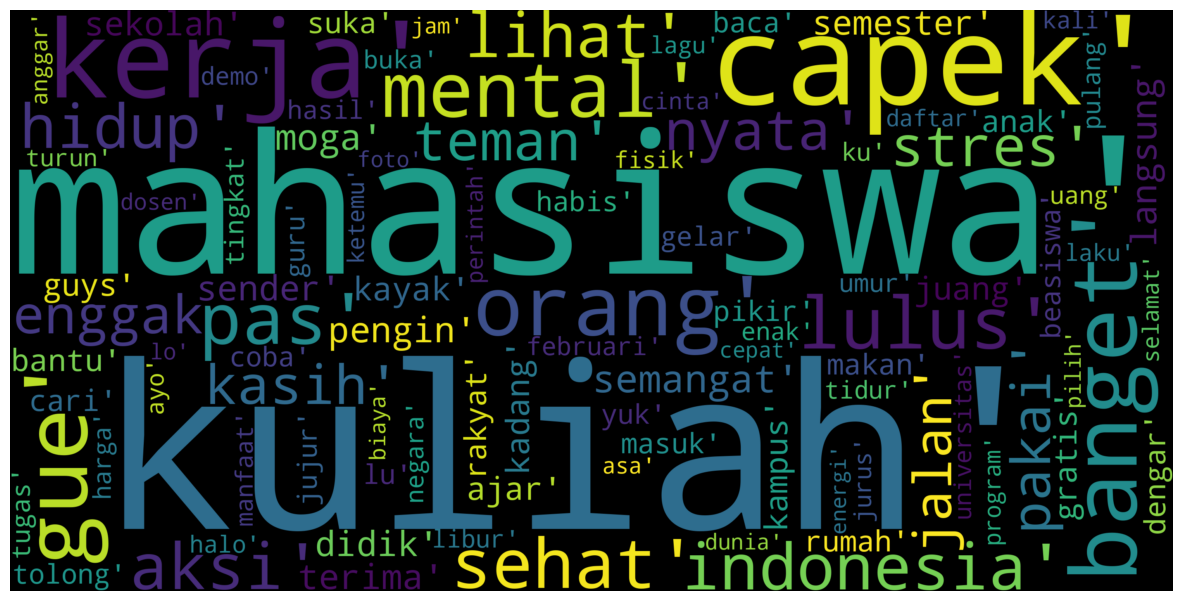

In [ ]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns

new_df=df[df['Indonesia Sentiment']=='Positive']
words = ' '.join(new_df['Text Filtering'])
wordcloud = WordCloud(stopwords=STOPWORDS,
                      background_color='black',
                      width=3000, height=1500, max_words = 100, collocations=False
                     ).generate(words)
plt.figure(figsize=(15, 15))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

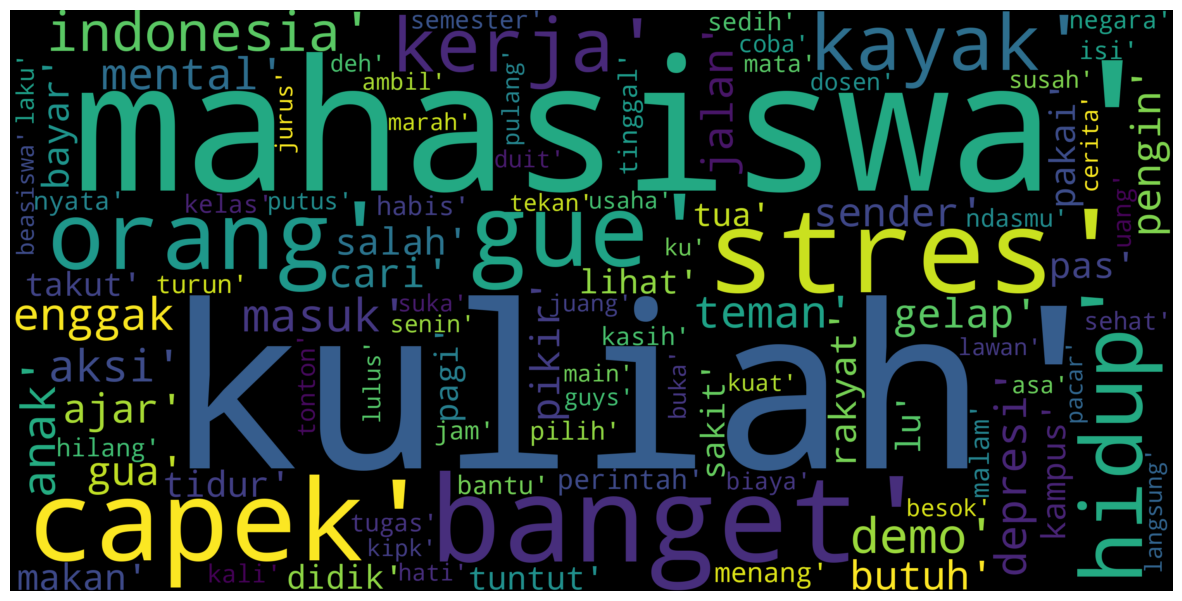

In [ ]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns

new_df=df[df['Indonesia Sentiment']=='Negative']
words = ' '.join(new_df['Text Filtering'])
wordcloud = WordCloud(stopwords=STOPWORDS,
                      background_color='black',
                      width=3000, height=1500, max_words = 100, collocations=False
                     ).generate(words)
plt.figure(figsize=(15, 15))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

# N-Gram Analysis

In [ ]:
def Gram_Analysis(Corpus, Gram, N):

  # Define Stopwords or import from nltk.corpus
  from nltk.corpus import stopwords
  from sklearn.feature_extraction.text import CountVectorizer #Import CountVectorizer
  Stopwords = stopwords.words('indonesian') # Or your desired list of stopwords

  # Vectorizer
  Vectorizer = CountVectorizer(ngram_range=(Gram, Gram))

  # Join the list of words in Corpus into a string before fit_transform
  Corpus = Corpus.apply(lambda x: ' '.join(x) if isinstance(x, list) else x)

  # N-Grams Matrix
  ngrams = Vectorizer.fit_transform(Corpus)

  # N-Grams Frequency
  Count = ngrams.sum(axis=0)

  # List of Words
  words = [(word, Count[0, idx]) for word, idx in Vectorizer.vocabulary_.items()]

  # Sort Descending With Key = Count
  words = sorted(words, key = lambda x:x[1], reverse = True)

  return sorted(words, key=lambda x: x[1], reverse=True)[:N]

In [ ]:
# Use dropna() so the base DataFrame is not affected
Positive = df[df["Indonesia Sentiment"] == "Positive"].dropna()
Negative = df[df["Indonesia Sentiment"] == "Negative"].dropna()

## Unigram of Tweets Based on Sentiments

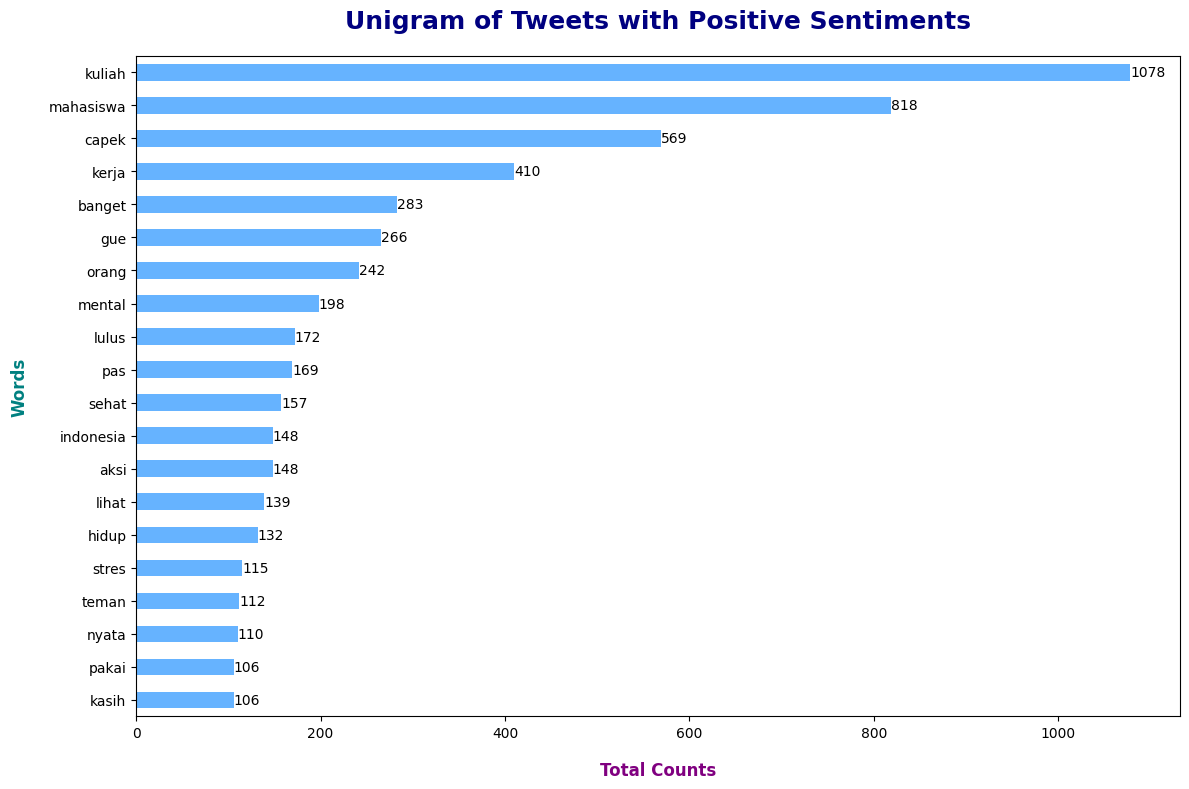

In [ ]:
# Finding Unigram for Positive Sentiment
words = Gram_Analysis(Positive["Text Filtering"], 1, 20)
Unigram_positive = pd.DataFrame(words, columns=["Words", "Counts"])

# Visualization for Positive Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Unigram_positive.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="#66b3ff") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize = 10)

plt.title("Unigram of Tweets with Positive Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

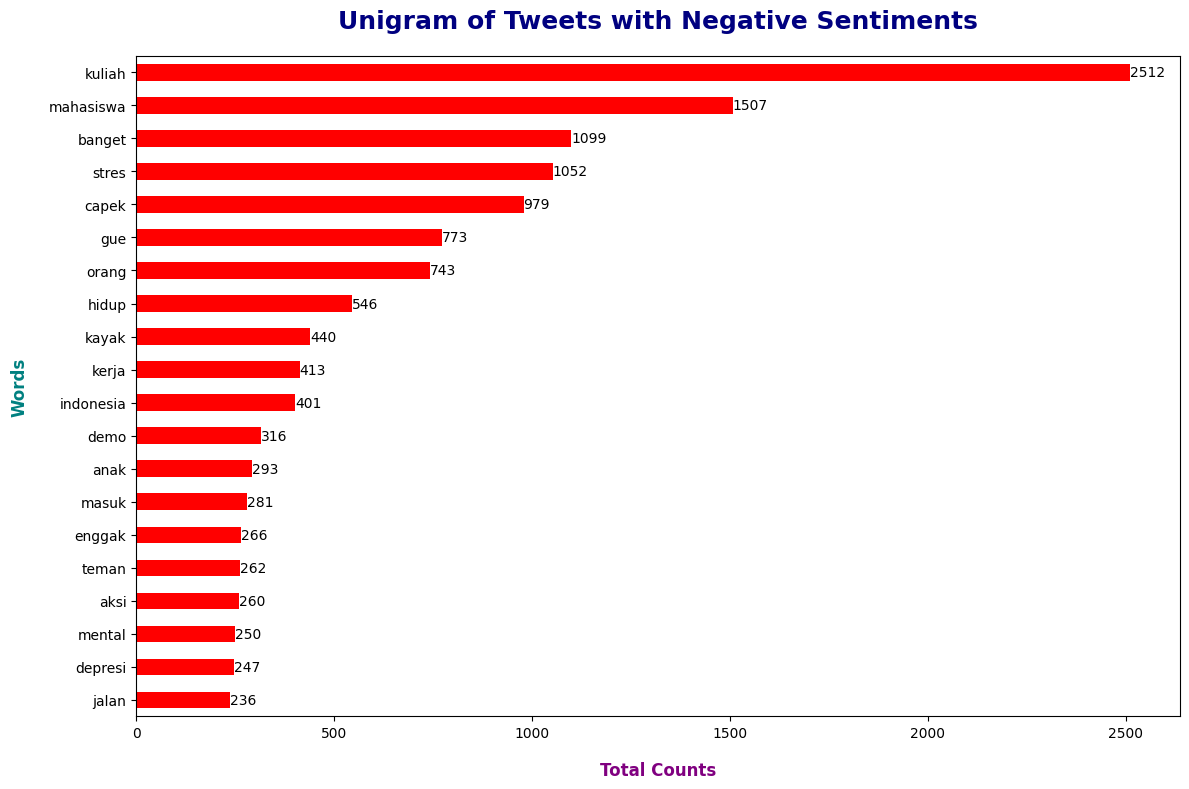

In [ ]:
# Finding Unigram for Negative Sentiment
words = Gram_Analysis(Negative["Text Filtering"], 1, 20)
Unigram_negative = pd.DataFrame(words, columns=["Words", "Counts"])

# Visualization for Negative Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Unigram_negative.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="red") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize = 10)

plt.title("Unigram of Tweets with Negative Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

## Bigram of Tweets Based On Sentiments

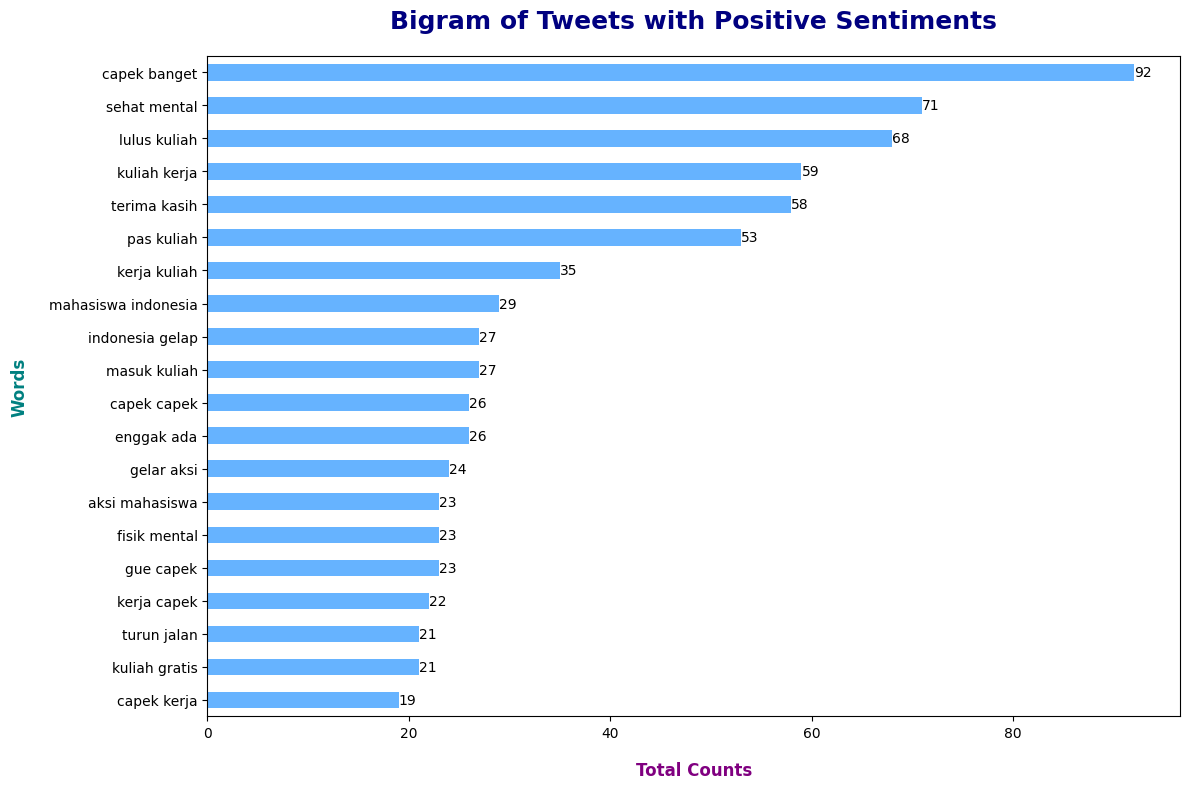

In [ ]:
# Finding Bigram for Positive Sentiment
words = Gram_Analysis(Positive["Text Filtering"], 2, 20)
Bigram_positive = pd.DataFrame(words, columns=["Words", "Counts"])

# Visualization for Positive Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Bigram_positive.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="#66b3ff") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize = 10)

plt.title("Bigram of Tweets with Positive Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

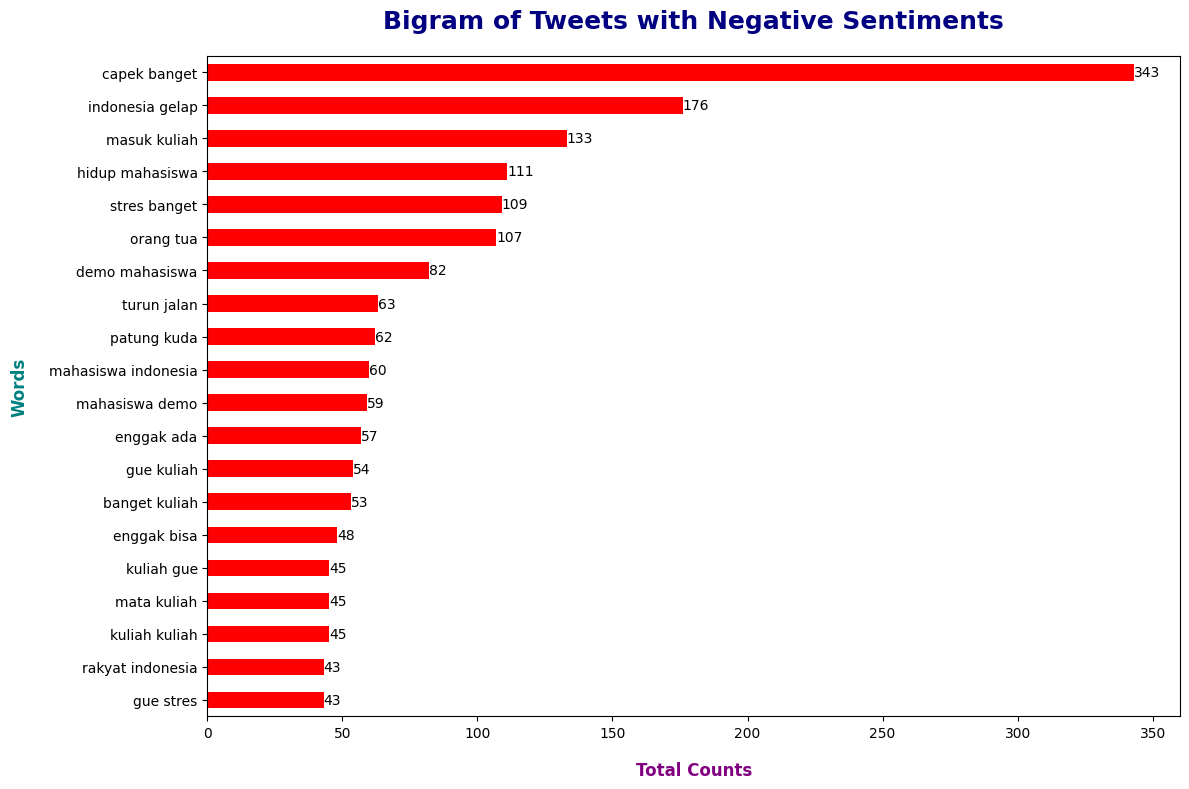

In [ ]:
# Finding Bigram for Negative Sentiment
words = Gram_Analysis(Negative["Text Filtering"], 2, 20)
Bigram_negative = pd.DataFrame(words, columns=["Words", "Counts"])

# Visualization for Negative Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Bigram_negative.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="red") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize = 10)

plt.title("Bigram of Tweets with Negative Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

## Trigram of Tweets Based On Sentiments

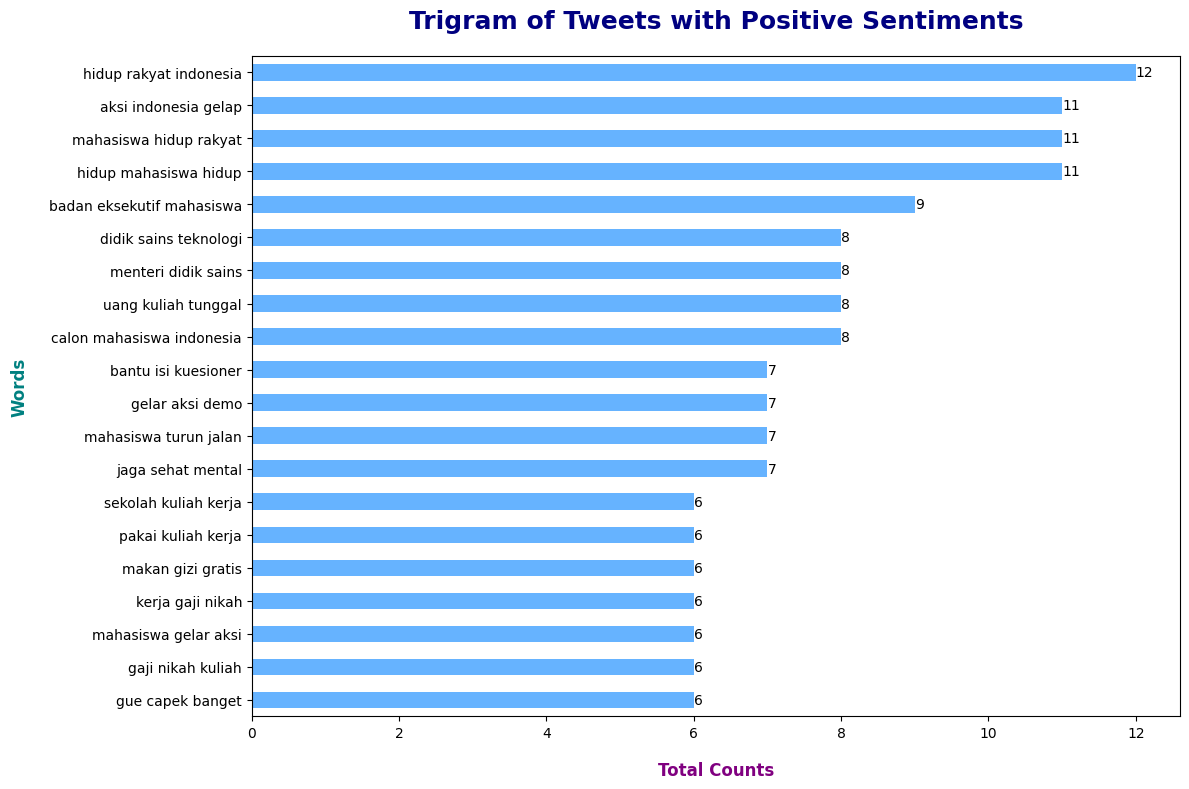

In [ ]:
# Finding Trigram
words = Gram_Analysis(Positive["Text Filtering"], 3, 20)
Trigram_positive = pd.DataFrame(words, columns = ["Words", "Counts"])

# Visualization for Positive Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Trigram_positive.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="#66b3ff") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize=10)

plt.title("Trigram of Tweets with Positive Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

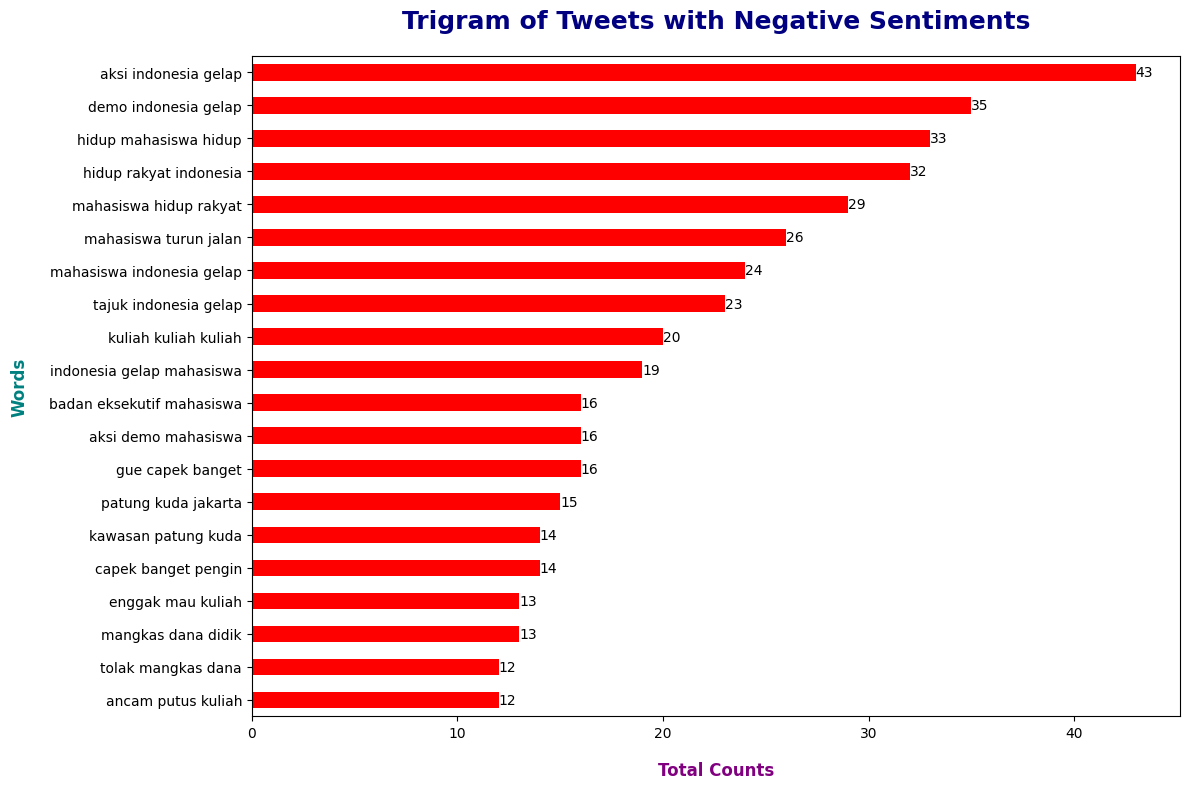

In [ ]:
# Finding Trigram
words = Gram_Analysis(Negative["Text Filtering"], 3, 20)
Trigram_negative = pd.DataFrame(words, columns = ["Words", "Counts"])

# Visualization for Negative Sentiment
plt.figure(figsize=(12, 8))  # Adjust figure size for better readability

# Create the bar chart
bars = Trigram_negative.groupby("Words")["Counts"].sum().sort_values().plot(kind="barh", color="red") # Use a more pleasant color

# Add labels to the end of each bar
for bar in bars.patches:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va = 'center', ha = 'left', fontsize=10)

plt.title("Trigram of Tweets with Negative Sentiments",  # More descriptive title
          loc="center", fontsize=18, color="#000080", pad=20, fontweight='bold')  # Improved title formatting
plt.xlabel("Total Counts", color="#800080", fontsize=12, labelpad=15, fontweight='bold') # Improved x-label
plt.ylabel("Words", color="#008080", fontsize=12, labelpad=15, fontweight='bold')    # Improved y-label
plt.xticks(rotation=0)
plt.yticks(fontsize=10) # Improved y-axis tick size

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()

# Modeling Data

## Inset TF-IDF

In [ ]:
import pandas as pd
import numpy as np

df_inset1 = pd.read_csv("sentiment results")

df_inset1

,Text Filtering,Polarity Score,Indonesia Sentiment
0,"['mahasiswa', 'ui', 'resah', 'kondisi', 'bangs...",-7,Negative
1,"['damn', 'besok', 'kuliah']",-1,Negative
2,"['gue', 'kuliah', 'passion', 'gue', 'passion',...",1,Positive
3,"['lu', 'stres', 'gas', 'lihat', 'dk', 'casual'...",-6,Negative
4,"['like', 'struggle', 'bayar', 'ukt', 'kuliah',...",-6,Negative
...,...,...,...
8313,"['ceramah', 'tarawih', 'serasa', 'kuliah']",-1,Negative
8314,"['takut', 'mahasiswa']",-3,Negative
8315,"['openn', 'yuk', 'guyssss', 'joki', 'cari', 'a...",-2,Negative
8316,"['stres', 'banget', 'pagi', 'ajg']",-7,Negative


## Splitting the Data

In [ ]:
# Define Y (This is the value we will predict)
X = df_inset1["Text Filtering"]
y = df_inset1["Indonesia Sentiment"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("Train Data:", len(X_train))
print("Test Data:", len(X_test))

Train Data: 6654
Test Data: 1664


## Implementation TF-IDF

In [ ]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer (max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('indonesian'))
response = tfidf_vectorizer.fit_transform(X_train)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


In [ ]:
df_tfidf = pd.DataFrame(response.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
df_tfidf.head()

,abai,abang,absen,acara,acc,adek,adik,adikadik,adil,admin,...,yaudah,ye,yogyakarta,you,your,youtube,yujiem,yuk,zaman,zona
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.426025,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Tranforming the Dataset

In [ ]:
X_train = tfidf_vectorizer.transform(X_train)
X_test  = tfidf_vectorizer.transform(X_test)
print(f'Inset TF IDF Data Transformed.')

Inset TF IDF Data Transformed.


## Evaluate Model Function

In [ ]:
from sklearn.ensemble import RandomForestClassifier

text_classifier1 = RandomForestClassifier(n_estimators=200, criterion='entropy', random_state=0)
text_classifier1.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=0)

In [ ]:
tfidf_predictions = text_classifier1.predict(X_test)

## Random Forest Model

Confusion matrix: 
 [[1023  112]
 [ 211  318]]
Classification report: 
               precision    recall  f1-score   support

    Negative       0.83      0.90      0.86      1135
    Positive       0.74      0.60      0.66       529

    accuracy                           0.81      1664
   macro avg       0.78      0.75      0.76      1664
weighted avg       0.80      0.81      0.80      1664

Inset Random Forest Classifier on TF-IDF Vectors: 0.8058894230769231


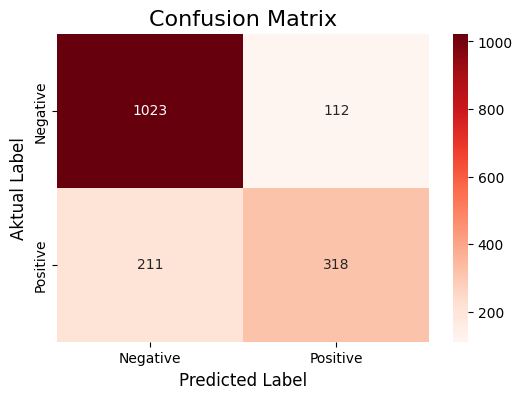

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

cm1 = confusion_matrix(y_test,tfidf_predictions)
cr1 = classification_report(y_test,tfidf_predictions)
rf_tfidf1 = accuracy_score(y_test,tfidf_predictions)
print('Confusion matrix: \n',cm1)
print('Classification report: \n',cr1)
print(f'Inset Random Forest Classifier on TF-IDF Vectors: {rf_tfidf1}')

# plot confusion matrix
plt.figure(figsize=(6,4))
sentiment_classes = ['Negative', 'Positive']
sns.heatmap(cm1, cmap=plt.cm.Reds, annot=True, fmt='d',
            xticklabels=sentiment_classes,
            yticklabels=sentiment_classes)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Aktual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

## Word Weighting Results

In [ ]:
import pandas as pd
model = {'Model':['Inset Random Forest Classifier - TFIDF Vectors'],
         'Accuracy Score':[rf_tfidf1]
         }
model_df = pd.DataFrame(model)
model_df

,Model,Accuracy Score
0,Inset Random Forest Classifier - TFIDF Vectors,0.805889


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


Param = {"C": np.logspace(-4, 4, 50), "penalty": ['l1', 'l2']}
grid_search = GridSearchCV(estimator = LogisticRegression(random_state = 42), param_grid = Param, scoring = "accuracy", cv = 10, verbose = 0, n_jobs = -1)

grid_search.fit(X_train, y_train)
best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
print("Best Parameters:", best_parameters)

Best Accuracy: 87.51 %
Best Parameters: {'C': np.float64(24.420530945486497), 'penalty': 'l2'}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
500 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_so